# Contraction-overlap safety analysis

This notebook evaluates whether rejecting contractions that produce excessive
normalized overlap prevents pathological configurations without substantially
altering the collective dynamics.

We compare three conditions:

- no contraction-overlap constraint;
- $\xi_{\mathrm{safe}}=0.80$;
- $\xi_{\mathrm{safe}}=0.75$.

All conditions contain the same realizations and differ only in the contraction
safety threshold. The simulations use $N=1000$, $\rho=0.80$, and
$\Delta t=0.05$.

## Import libraries and settings

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Simulation parameters
DELTA_T = 0.05

# Data paths
DATA_ROOT = Path("./data")

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CONDITIONS = {
    "none": {
        "label": r"No safety constraint",
        "xi_safe": np.nan,
        "folder": DATA_ROOT / "xi_safe=None",
        "color": "tab:blue",
    },
    "0.80": {
        "label": r"$\xi_{\mathrm{safe}}=0.80$",
        "xi_safe": 0.80,
        "folder": DATA_ROOT / "xi_safe=0_80",
        "color": "tab:orange",
    },
    "0.75": {
        "label": r"$\xi_{\mathrm{safe}}=0.75$",
        "xi_safe": 0.75,
        "folder": DATA_ROOT / "xi_safe=0_75",
        "color": "tab:green",
    },
}

TABLE_PATHS = {
    "order": Path(
        "processed/order_parameters/order_parameters.parquet"
    ),
    "motion": Path(
        "processed/motion/motion.parquet"
    ),
    "deformation": Path(
        "processed/deformation/deformation.parquet"
    ),
    "overlap": Path(
        "processed/overlap/overlap.parquet"
    ),
}

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Loading and checking data

In [2]:
tables_by_condition = {}

for condition, configuration in CONDITIONS.items():
    condition_tables = {}

    for table_name, relative_path in TABLE_PATHS.items():
        filepath = (
            configuration["folder"]
            / relative_path
        )

        table = pd.read_parquet(filepath).copy()

        table["condition"] = condition
        table["xi_safe"] = configuration["xi_safe"]
        table["physical_time"] = (
            table["step"] * DELTA_T
        )

        condition_tables[table_name] = table

    tables_by_condition[condition] = condition_tables


order_parameters = pd.concat(
    [
        tables_by_condition[condition]["order"]
        for condition in CONDITIONS
    ],
    ignore_index=True,
)

motion = pd.concat(
    [
        tables_by_condition[condition]["motion"]
        for condition in CONDITIONS
    ],
    ignore_index=True,
)

deformation = pd.concat(
    [
        tables_by_condition[condition]["deformation"]
        for condition in CONDITIONS
    ],
    ignore_index=True,
)

overlap = pd.concat(
    [
        tables_by_condition[condition]["overlap"]
        for condition in CONDITIONS
    ],
    ignore_index=True,
)

In [3]:
TABLES = {
    "order": order_parameters,
    "motion": motion,
    "deformation": deformation,
    "overlap": overlap,
}

summary_rows = []

for table_name, table in TABLES.items():
    for condition, condition_data in table.groupby(
        "condition",
        sort=False,
    ):
        summary_rows.append({
            "table": table_name,
            "condition": condition,
            "rows": len(condition_data),
            "realizations": condition_data["seed"].nunique(),
            "N": condition_data["N"].unique().tolist(),
            "rho": condition_data["rho"].unique().tolist(),
            "first_step": condition_data["step"].min(),
            "last_step": condition_data["step"].max(),
            "number_of_saved_steps": (
                condition_data["step"].nunique()
            ),
            "duplicates": condition_data.duplicated(
                subset=["N", "rho", "seed", "step"],
            ).sum(),
        })

summary = pd.DataFrame(summary_rows)

display(summary)

,table,condition,rows,realizations,N,rho,first_step,last_step,number_of_saved_steps,duplicates
0,order,none,3612,12,[1000],[0.8],0,30000,301,0
1,order,0.80,3612,12,[1000],[0.8],0,30000,301,0
2,order,0.75,3612,12,[1000],[0.8],0,30000,301,0
3,motion,none,3612,12,[1000],[0.8],0,30000,301,0
4,motion,0.80,3612,12,[1000],[0.8],0,30000,301,0
5,motion,0.75,3612,12,[1000],[0.8],0,30000,301,0
6,deformation,none,3600,12,[1000],[0.8],100,30000,300,0
7,deformation,0.80,3600,12,[1000],[0.8],100,30000,300,0
8,deformation,0.75,3600,12,[1000],[0.8],100,30000,300,0
9,overlap,none,3600,12,[1000],[0.8],100,30000,300,0


In [4]:
seed_sets = {
    condition: set(
        tables_by_condition[condition]["order"]["seed"]
    )
    for condition in CONDITIONS
}

reference_seeds = seed_sets["none"]

same_seeds = all(
    seeds == reference_seeds
    for seeds in seed_sets.values()
)

print("Same seeds in all conditions:", same_seeds)
print("Number of paired realizations:", len(reference_seeds))

assert same_seeds
assert summary["duplicates"].eq(0).all()

Same seeds in all conditions: True
Number of paired realizations: 12


## Microscopic effect of the contraction-overlap safety criterion

Each output interval contains the largest normalized overlap observed during
100 simulation steps, corresponding to five units of physical time.

For overlap maxima, solid lines represent the median across realizations and
shaded regions represent the interquartile range. Intervals without contraction
attempts or accepted contractions are excluded from the corresponding maximum.

The cumulative rejection fraction is calculated by pooling all contraction
events across realizations:

$$
P_{\mathrm{rej}}(t)
=
\frac{\sum_{t'\leq t}N_{\mathrm{rejected}}(t')}
{\sum_{t'\leq t}N_{\mathrm{attempted}}(t')}.
$$

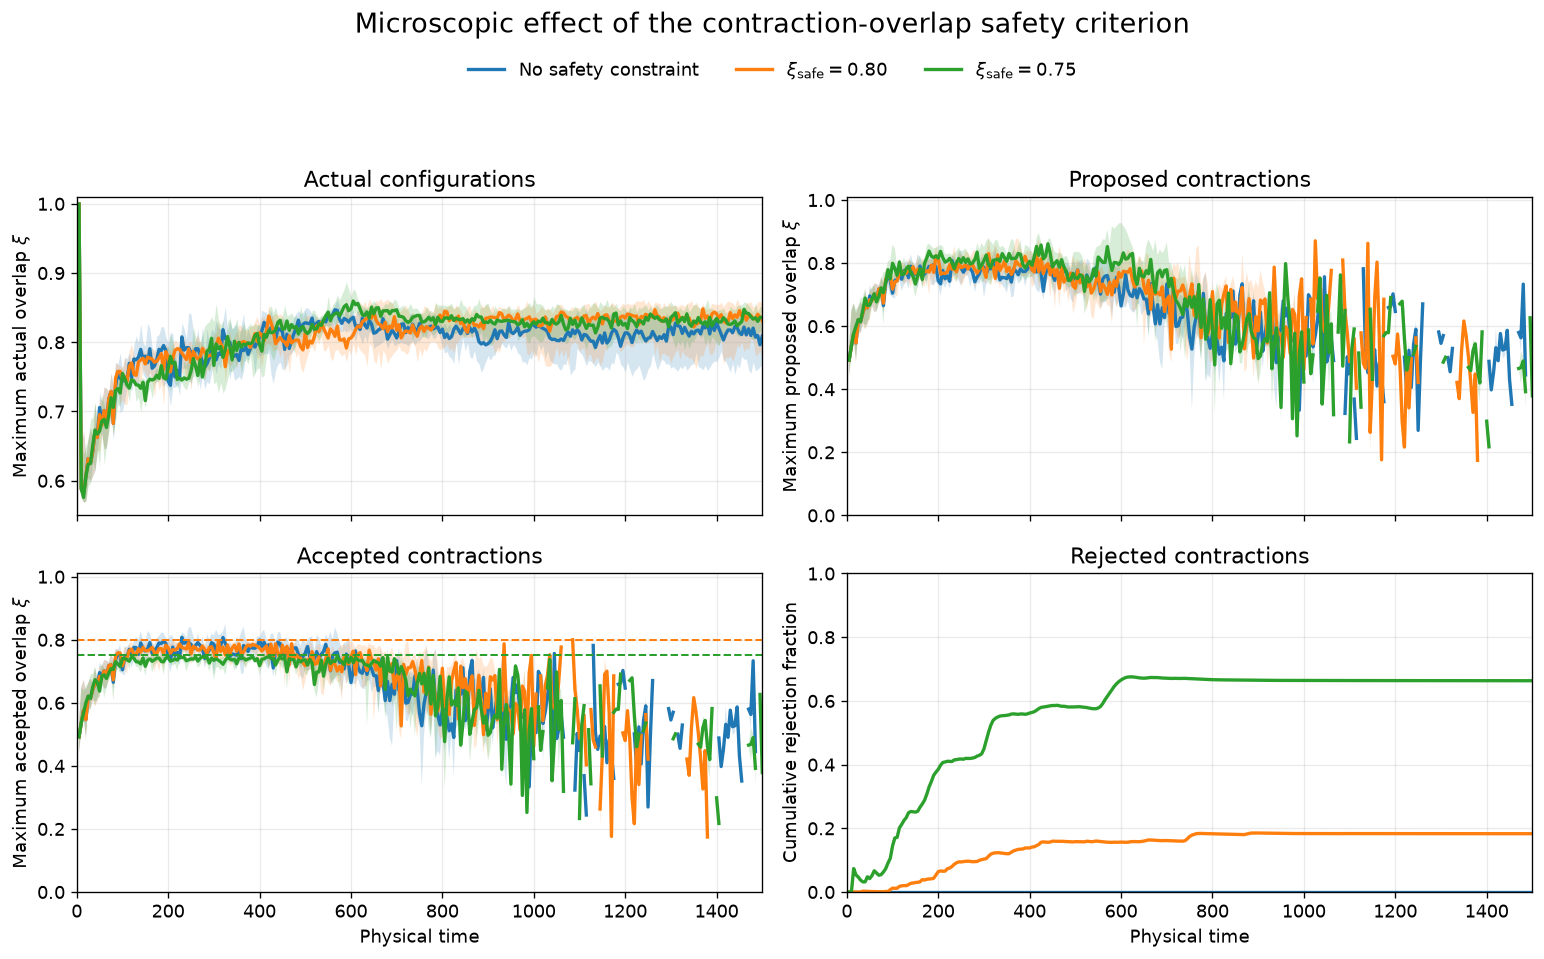

In [5]:
# Work on a copy to preserve the original processed data
deformation_plot = deformation.copy()

# A zero maximum means that no corresponding event occurred
deformation_plot.loc[
    deformation_plot["contraction_attempts"] == 0,
    "max_contraction_proposed_overlap",
] = np.nan

deformation_plot.loc[
    deformation_plot["contraction_events"] == 0,
    "max_contraction_accepted_overlap",
] = np.nan


def calculate_median_iqr(
    data: pd.DataFrame,
    value_column: str,
) -> pd.DataFrame:
    """Calculate the median and interquartile range at each time."""

    return (
        data
        .groupby(
            ["condition", "physical_time"],
            as_index=False,
        )[value_column]
        .agg(
            median="median",
            q25=lambda values: values.quantile(0.25),
            q75=lambda values: values.quantile(0.75),
        )
    )


def plot_median_iqr(
    ax,
    data: pd.DataFrame,
    value_column: str,
    ylabel: str,
) -> None:
    """Plot the temporal median and interquartile range."""

    summary = calculate_median_iqr(
        data=data,
        value_column=value_column,
    )

    for condition, configuration in CONDITIONS.items():
        condition_data = summary.loc[
            summary["condition"] == condition
        ]

        physical_time = condition_data[
            "physical_time"
        ].to_numpy()

        median = condition_data[
            "median"
        ].to_numpy()

        q25 = condition_data[
            "q25"
        ].to_numpy()

        q75 = condition_data[
            "q75"
        ].to_numpy()

        ax.plot(
            physical_time,
            median,
            color=configuration["color"],
            linewidth=2,
            label=configuration["label"],
        )

        ax.fill_between(
            physical_time,
            q25,
            q75,
            color=configuration["color"],
            alpha=0.18,
            linewidth=0,
        )

    ax.set_ylabel(ylabel)


# Pool contraction events across realizations
rejection_time_series = (
    deformation
    .groupby(
        ["condition", "physical_time"],
        as_index=False,
    )[
        [
            "contraction_overlap_rejections",
            "contraction_attempts",
        ]
    ]
    .sum()
    .sort_values(
        ["condition", "physical_time"]
    )
)

rejection_time_series[
    "cumulative_rejections"
] = (
    rejection_time_series
    .groupby("condition")[
        "contraction_overlap_rejections"
    ]
    .cumsum()
)

rejection_time_series[
    "cumulative_attempts"
] = (
    rejection_time_series
    .groupby("condition")[
        "contraction_attempts"
    ]
    .cumsum()
)

rejection_time_series[
    "cumulative_rejection_fraction"
] = np.divide(
    rejection_time_series["cumulative_rejections"],
    rejection_time_series["cumulative_attempts"],
    out=np.full(
        len(rejection_time_series),
        np.nan,
    ),
    where=(
        rejection_time_series[
            "cumulative_attempts"
        ].to_numpy()
        > 0
    ),
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8),
    sharex=True,
)

plot_median_iqr(
    ax=axes[0, 0],
    data=overlap,
    value_column="max_normalized_overlap",
    ylabel=r"Maximum actual overlap $\xi$",
)

plot_median_iqr(
    ax=axes[0, 1],
    data=deformation_plot,
    value_column="max_contraction_proposed_overlap",
    ylabel=r"Maximum proposed overlap $\xi$",
)

plot_median_iqr(
    ax=axes[1, 0],
    data=deformation_plot,
    value_column="max_contraction_accepted_overlap",
    ylabel=r"Maximum accepted overlap $\xi$",
)

# Show the two tested safety thresholds
axes[1, 0].axhline(
    0.80,
    color=CONDITIONS["0.80"]["color"],
    linestyle="--",
    linewidth=1.2,
)

axes[1, 0].axhline(
    0.75,
    color=CONDITIONS["0.75"]["color"],
    linestyle="--",
    linewidth=1.2,
)

for condition, configuration in CONDITIONS.items():
    condition_data = rejection_time_series.loc[
        rejection_time_series["condition"] == condition
    ]

    axes[1, 1].plot(
        condition_data["physical_time"],
        condition_data[
            "cumulative_rejection_fraction"
        ],
        color=configuration["color"],
        linewidth=2,
        label=configuration["label"],
    )

axes[1, 1].set_ylabel(
    "Cumulative rejection fraction"
)

panel_titles = [
    "Actual configurations",
    "Proposed contractions",
    "Accepted contractions",
    "Rejected contractions",
]

for ax, title in zip(
    axes.flat,
    panel_titles,
):
    ax.set_title(title)
    ax.set_xlim(
        0,
        overlap["physical_time"].max(),
    )

for ax in axes[1]:
    ax.set_xlabel("Physical time")

axes[0, 0].set_ylim(0.55, 1.01)
axes[0, 1].set_ylim(0, 1.01)
axes[1, 0].set_ylim(0, 1.01)
axes[1, 1].set_ylim(0, 1)

handles, labels = (
    axes[0, 0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.96),
)

fig.suptitle(
    "Microscopic effect of the contraction-overlap safety criterion",
    fontsize=16,
    y=0.995,
)

fig.tight_layout(
    rect=(0, 0, 1, 0.90)
)

fig.savefig(
    FIGURE_DIR / "microscopic_contraction_safety.pdf",
    bbox_inches="tight",
)

fig.savefig(
    FIGURE_DIR / "microscopic_contraction_safety.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The safety criterion correctly bounds the overlap introduced by accepted
contractions. Without a constraint, accepted contractions can reach normalized
overlaps above $0.9$, whereas the constrained simulations satisfy their
respective thresholds.

However, $\xi_{\mathrm{safe}}=0.75$ rejects approximately two thirds of all
contraction attempts, indicating a strong modification of the deformation
dynamics. In contrast, $\xi_{\mathrm{safe}}=0.80$ rejects approximately $18\%$
of the attempts and primarily removes the most extreme contractions.

The maximum overlap in the actual configurations is not reduced by the safety
criterion. Therefore, contraction filtering prevents unsafe instantaneous
shape changes but does not control overlaps subsequently generated by the
collective dynamics.

In [6]:
event_summary = (
    deformation
    .groupby(
        "condition",
        as_index=False,
    )[
        [
            "round_elongation_successes",
            "contraction_events",
            "contraction_overlap_rejections",
            "contraction_attempts",
        ]
    ]
    .sum()
)

event_summary["rejection_fraction"] = np.divide(
    event_summary["contraction_overlap_rejections"],
    event_summary["contraction_attempts"],
    out=np.zeros(len(event_summary)),
    where=event_summary["contraction_attempts"] > 0,
)

baseline_contractions = event_summary.loc[
    event_summary["condition"] == "none",
    "contraction_events",
].iloc[0]

event_summary["accepted_relative_to_baseline"] = (
    event_summary["contraction_events"]
    / baseline_contractions
)

event_summary["net_elongated_balance"] = (
    event_summary["round_elongation_successes"]
    - event_summary["contraction_events"]
)

number_of_realizations = (
    order_parameters["seed"].nunique()
)

event_summary["net_elongated_per_realization"] = (
    event_summary["net_elongated_balance"]
    / number_of_realizations
)

event_summary["condition_label"] = (
    event_summary["condition"]
    .map({
        condition: configuration["label"]
        for condition, configuration in CONDITIONS.items()
    })
)

display(
    event_summary[
        [
            "condition_label",
            "round_elongation_successes",
            "contraction_events",
            "contraction_overlap_rejections",
            "rejection_fraction",
            "accepted_relative_to_baseline",
            "net_elongated_per_realization",
        ]
    ]
)

,condition_label,round_elongation_successes,contraction_events,contraction_overlap_rejections,rejection_fraction,accepted_relative_to_baseline,net_elongated_per_realization
0,$\xi_{\mathrm{safe}}=0.75$,40369,28481,56062,0.663118,0.987175,990.666667
1,$\xi_{\mathrm{safe}}=0.80$,39985,28647,6410,0.182845,0.992929,944.833333
2,No safety constraint,40224,28851,0,0.000000,1.000000,947.750000


A large rejection fraction does not imply a comparable reduction in the number
of accepted contractions. Rejected contractions can be attempted again at
later times, when the local configuration has changed.

Consequently, the safety criterion mainly introduces a waiting mechanism.
Nevertheless, small changes in the balance between successful elongations and
accepted contractions can produce measurable changes in the final elongated
fraction.

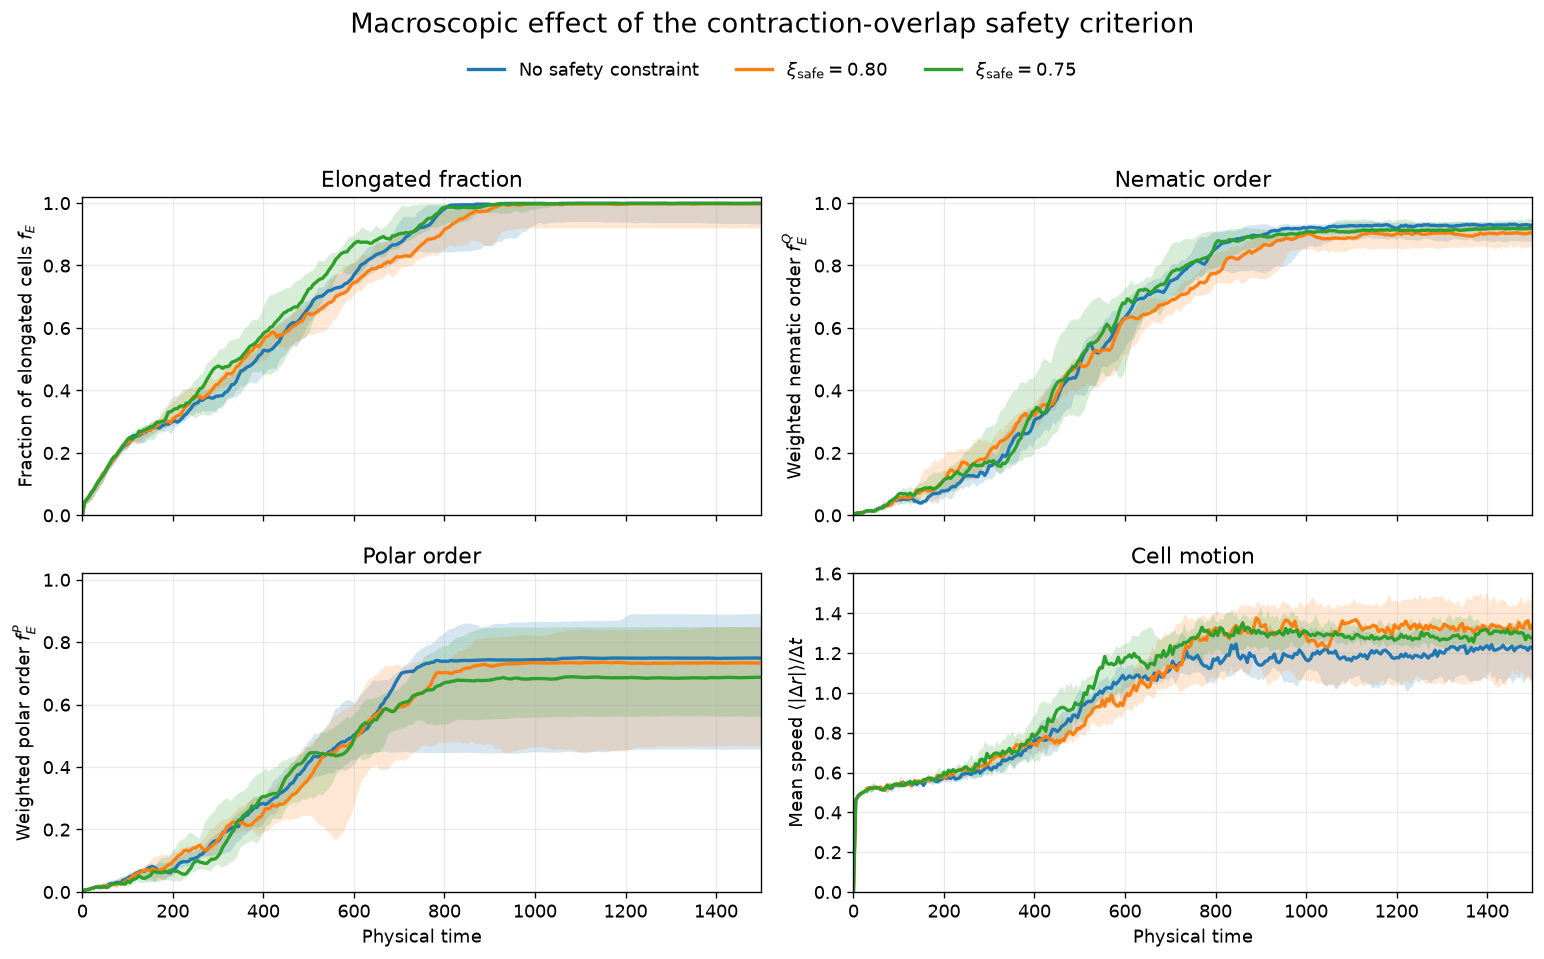

In [7]:
motion_plot = motion.copy()

motion_plot["mean_speed"] = (
    motion_plot["mean_step_displacement"]
    / DELTA_T
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8),
    sharex=True,
)

plot_median_iqr(
    ax=axes[0, 0],
    data=order_parameters,
    value_column="fraction_elongated",
    ylabel=r"Fraction of elongated cells $f_E$",
)

plot_median_iqr(
    ax=axes[0, 1],
    data=order_parameters,
    value_column="nematic_2",
    ylabel=r"Weighted nematic order $f_E^Q$",
)

plot_median_iqr(
    ax=axes[1, 0],
    data=order_parameters,
    value_column="polar_2",
    ylabel=r"Weighted polar order $f_E^P$",
)

plot_median_iqr(
    ax=axes[1, 1],
    data=motion_plot,
    value_column="mean_speed",
    ylabel=r"Mean speed $\langle|\Delta r|\rangle/\Delta t$",
)

panel_titles = [
    "Elongated fraction",
    "Nematic order",
    "Polar order",
    "Cell motion",
]

for ax, title in zip(
    axes.flat,
    panel_titles,
):
    ax.set_title(title)
    ax.set_xlim(
        0,
        order_parameters["physical_time"].max(),
    )

for ax in axes[1]:
    ax.set_xlabel("Physical time")

axes[0, 0].set_ylim(0, 1.02)
axes[0, 1].set_ylim(0, 1.02)
axes[1, 0].set_ylim(0, 1.02)
axes[1, 1].set_ylim(0, 1.6)

handles, labels = (
    axes[0, 0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.96),
)

fig.suptitle(
    "Macroscopic effect of the contraction-overlap safety criterion",
    fontsize=16,
    y=0.995,
)

fig.tight_layout(
    rect=(0, 0, 1, 0.90)
)

fig.savefig(
    FIGURE_DIR / "macroscopic_contraction_safety.pdf",
    bbox_inches="tight",
)

fig.savefig(
    FIGURE_DIR / "macroscopic_contraction_safety.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Despite the large difference in rejection frequency, all three conditions
display the same qualitative collective dynamics. Rejected contractions are
generally attempted again and can be accepted after the local configuration
changes.

The threshold $\xi_{\mathrm{safe}}=0.80$ remains close to the unconstrained
dynamics in the elongated fraction and orientational order. In contrast,
$\xi_{\mathrm{safe}}=0.75$ produces earlier and more persistent elongation and
a modest increase in cell speed. Therefore, the lower threshold modifies the
timing of the deformation dynamics even though the total number of accepted
contractions remains similar.

### Paired late-time comparison

To determine whether the safety criterion produces a systematic macroscopic
change, we average each observable over the final 20% of the simulation.

Because the same initial seeds were used in all conditions, every realization
is compared with its corresponding baseline realization. This paired
comparison reduces the contribution of realization-to-realization variability.

The confidence intervals shown below are bootstrap confidence intervals for
the mean paired difference. This analysis characterizes the late-time regime;
it does not by itself prove that the system has reached a stationary state.

In [8]:
# Fraction of the trajectory used for the late-time comparison
LATE_TIME_FRACTION = 0.20

final_time = min(
    order_parameters["physical_time"].max(),
    motion["physical_time"].max(),
)

late_time_start = (
    1 - LATE_TIME_FRACTION
) * final_time

print(
    f"Late-time window: "
    f"{late_time_start:.1f} <= t <= {final_time:.1f}"
)


# Calculate the instantaneous mean speed
motion_analysis = motion.copy()

motion_analysis["mean_speed"] = (
    motion_analysis["mean_step_displacement"]
    / DELTA_T
)


# Average each observable over the late-time window
late_order = (
    order_parameters[
        order_parameters["physical_time"] >= late_time_start
    ]
    .groupby(
        ["condition", "seed"],
        as_index=False,
    )[
        [
            "fraction_elongated",
            "nematic_2",
            "polar_2",
        ]
    ]
    .mean()
)

late_motion = (
    motion_analysis[
        motion_analysis["physical_time"] >= late_time_start
    ]
    .groupby(
        ["condition", "seed"],
        as_index=False,
    )[["mean_speed"]]
    .mean()
)

late_time_by_seed = late_order.merge(
    late_motion,
    on=["condition", "seed"],
    validate="one_to_one",
)


# Bootstrap confidence interval for the mean paired difference
def bootstrap_mean_ci(
    values,
    n_bootstrap=50_000,
    confidence_level=0.95,
    rng=None,
):
    """Return a bootstrap confidence interval for the sample mean."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if rng is None:
        rng = np.random.default_rng()

    bootstrap_samples = rng.choice(
        values,
        size=(n_bootstrap, values.size),
        replace=True,
    )

    bootstrap_means = bootstrap_samples.mean(axis=1)

    alpha = 1 - confidence_level

    return np.quantile(
        bootstrap_means,
        [
            alpha / 2,
            1 - alpha / 2,
        ],
    )


METRICS = {
    "fraction_elongated": r"$f_E$",
    "nematic_2": r"$f_E^Q$",
    "polar_2": r"$f_E^P$",
    "mean_speed": r"$\langle |\Delta r| \rangle / \Delta t$",
}

BASELINE_CONDITION = "none"
TEST_CONDITIONS = ["0.80", "0.75"]

baseline = (
    late_time_by_seed[
        late_time_by_seed["condition"]
        == BASELINE_CONDITION
    ]
    .set_index("seed")
    .sort_index()
)

paired_rows = []

for condition in TEST_CONDITIONS:
    current = (
        late_time_by_seed[
            late_time_by_seed["condition"] == condition
        ]
        .set_index("seed")
        .sort_index()
    )

    common_seeds = baseline.index.intersection(
        current.index
    )

    for metric, metric_label in METRICS.items():
        differences = (
            current.loc[common_seeds, metric]
            - baseline.loc[common_seeds, metric]
        )

        for seed, difference in differences.items():
            paired_rows.append(
                {
                    "condition": condition,
                    "seed": seed,
                    "metric": metric,
                    "metric_label": metric_label,
                    "difference": difference,
                }
            )

paired_differences = pd.DataFrame(paired_rows)


# Summarize the paired differences
rng = np.random.default_rng(12345)
summary_rows = []

for metric, metric_label in METRICS.items():
    baseline_mean = baseline[metric].mean()

    for condition in TEST_CONDITIONS:
        values = paired_differences.loc[
            (
                paired_differences["condition"]
                == condition
            )
            & (
                paired_differences["metric"]
                == metric
            ),
            "difference",
        ].to_numpy()

        ci_lower, ci_upper = bootstrap_mean_ci(
            values,
            rng=rng,
        )

        summary_rows.append(
            {
                "observable": metric_label,
                "condition": CONDITIONS[
                    condition
                ]["label"],
                "mean_difference": values.mean(),
                "relative_difference_percent": (
                    100 * values.mean() / baseline_mean
                ),
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "positive_realizations": (
                    values > 0
                ).sum(),
                "number_of_realizations": values.size,
            }
        )

paired_summary = pd.DataFrame(summary_rows)

display(
    paired_summary.round(
        {
            "mean_difference": 4,
            "relative_difference_percent": 2,
            "ci_lower": 4,
            "ci_upper": 4,
        }
    )
)

Late-time window: 1200.0 <= t <= 1500.0


,observable,condition,mean_difference,relative_difference_percent,ci_lower,ci_upper,positive_realizations,number_of_realizations
0,$f_E$,$\xi_{\mathrm{safe}}=0.80$,-0.0034,-0.35,-0.0619,0.0607,4,12
1,$f_E$,$\xi_{\mathrm{safe}}=0.75$,0.0425,4.48,-0.0021,0.0933,7,12
2,$f_E^Q$,$\xi_{\mathrm{safe}}=0.80$,-0.0120,-1.35,-0.0630,0.0431,5,12
3,$f_E^Q$,$\xi_{\mathrm{safe}}=0.75$,0.0306,3.43,-0.0154,0.0830,6,12
4,$f_E^P$,$\xi_{\mathrm{safe}}=0.80$,-0.0287,-4.37,-0.2295,0.1842,6,12
5,$f_E^P$,$\xi_{\mathrm{safe}}=0.75$,0.0352,5.36,-0.1362,0.2247,7,12
6,$\langle |\Delta r| \rangle / \Delta t$,$\xi_{\mathrm{safe}}=0.80$,0.0747,6.21,-0.0557,0.2077,8,12
7,$\langle |\Delta r| \rangle / \Delta t$,$\xi_{\mathrm{safe}}=0.75$,0.1041,8.67,0.0239,0.1911,8,12


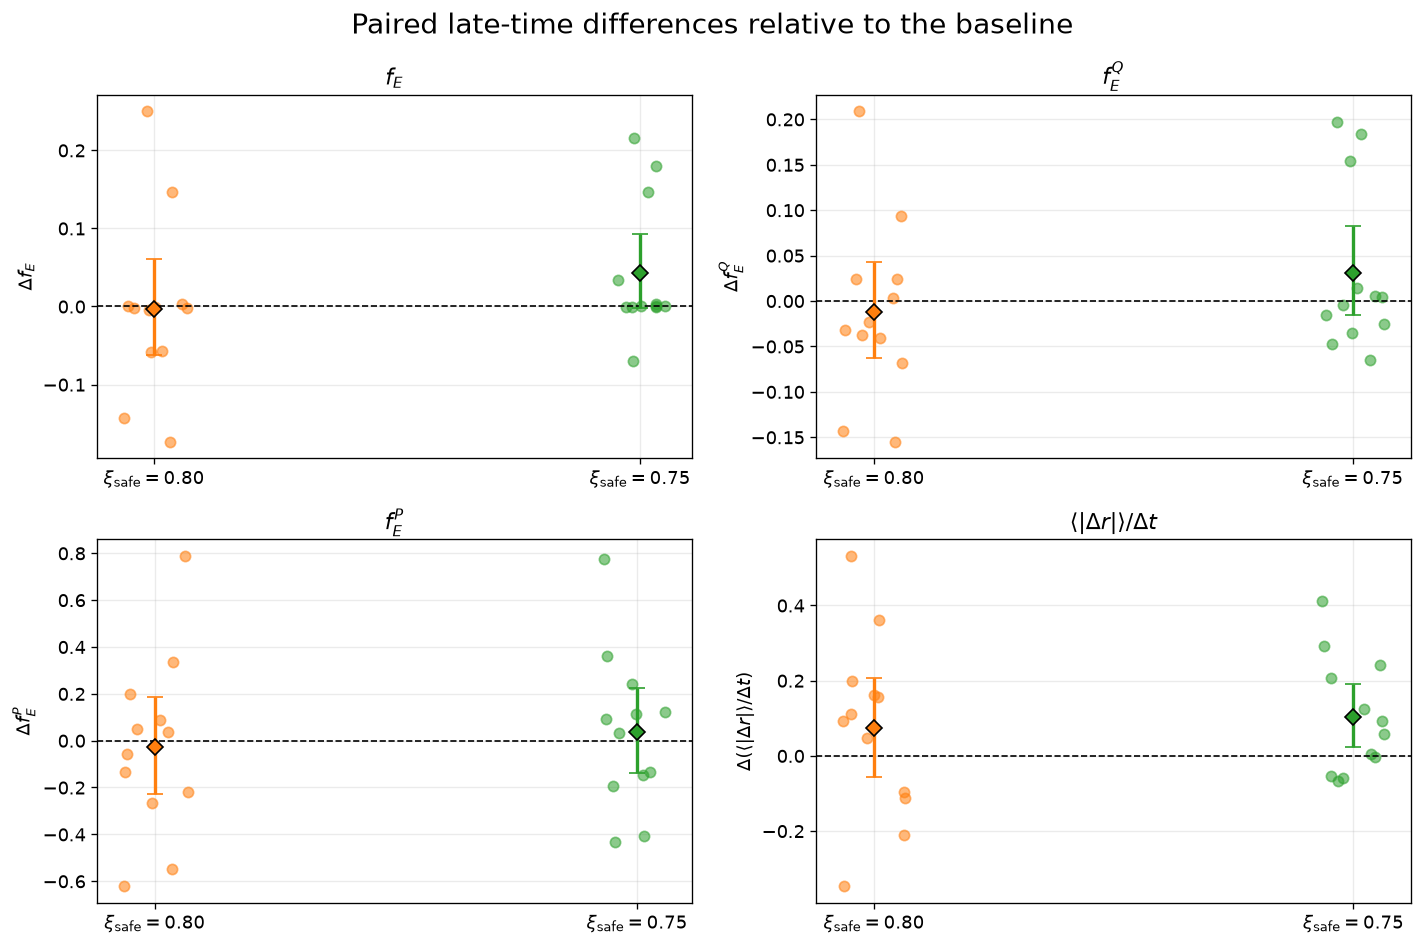

In [13]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
)

axes = axes.ravel()

Y_LABELS = {
    "fraction_elongated": r"$\Delta f_E$",
    "nematic_2": r"$\Delta f_E^Q$",
    "polar_2": r"$\Delta f_E^P$",
    "mean_speed": (
        r"$\Delta\left("
        r"\langle |\Delta r| \rangle / \Delta t"
        r"\right)$"
    ),
}

rng = np.random.default_rng(24680)

for ax, (metric, title) in zip(
    axes,
    METRICS.items(),
):
    for x_position, condition in enumerate(
        TEST_CONDITIONS
    ):
        values = paired_differences.loc[
            (
                paired_differences["condition"]
                == condition
            )
            & (
                paired_differences["metric"]
                == metric
            ),
            "difference",
        ].to_numpy()

        jitter = rng.uniform(
            -0.07,
            0.07,
            size=values.size,
        )

        color = CONDITIONS[condition]["color"]

        # Individual paired differences
        ax.scatter(
            x_position + jitter,
            values,
            color=color,
            alpha=0.55,
            s=38,
            zorder=2,
        )

        # Mean paired difference and bootstrap confidence interval
        summary_row = paired_summary[
            (
                paired_summary["condition"]
                == CONDITIONS[condition]["label"]
            )
            & (
                paired_summary["observable"]
                == title
            )
        ].iloc[0]

        mean_difference = summary_row[
            "mean_difference"
        ]
        ci_lower = summary_row["ci_lower"]
        ci_upper = summary_row["ci_upper"]

        ax.errorbar(
            x_position,
            mean_difference,
            yerr=[
                [mean_difference - ci_lower],
                [ci_upper - mean_difference],
            ],
            fmt="D",
            color=color,
            markeredgecolor="black",
            markersize=7,
            capsize=5,
            linewidth=2,
            zorder=3,
        )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
    )

    ax.set_xticks(
        range(len(TEST_CONDITIONS))
    )

    ax.set_xticklabels(
        [
            CONDITIONS[condition]["label"]
            for condition in TEST_CONDITIONS
        ]
    )

    ax.set(
        title=title,
        ylabel=Y_LABELS[metric],
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )

fig.suptitle(
    "Paired late-time differences relative to the baseline",
    fontsize=17,
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "paired_late_time_contraction_safety.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The contraction-overlap safety criterion primarily acts as a microscopic
filter. Although $\xi_{\mathrm{safe}}=0.80$ rejects approximately 18% of the
proposed contractions, it produces only small late-time differences relative
to the unconstrained model.

A stricter threshold, $\xi_{\mathrm{safe}}=0.75$, rejects many repeated
contraction attempts and produces a more noticeable increase in the elongated
fraction and cell speed. Therefore, it begins to modify the macroscopic
dynamics rather than merely preventing unsafe contractions.

We consequently select

$$
\xi_{\mathrm{safe}}=0.80
$$

as a preliminary value. It prevents contractions with very large overlap
while preserving the behavior of the original model within the variability
observed across realizations.